Suite à l'identification du Player_42 comme cible prioritaire, je vais maintenant comparer ce joueur à notre attaquant actuel qui part (Striker_Outgoing). 

# Objectif : regarder que nous ne perdons pas au change.

Je vais générer un petit dataset spécifique pour cette comparaison, incluant des données spatiales simulées pour visualiser les tirs.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

comparison_data = {
    'Metric': ['Non-Penalty xG/90', 'Goals/90', 'Shots/90', 'Pressures/90', 'Aerial Wins %', 'Deep Completions/90'],
    'Player_42': [0.58, 0.44, 3.8, 22.5, 48.0, 1.8],
    'Outgoing': [0.45, 0.52, 2.9, 18.0, 42.0, 1.2],
    'League_Avg': [0.35, 0.35, 2.2, 16.5, 45.0, 1.0]
}
df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.melt(id_vars="Metric", var_name="Player", value_name="Value")

np.random.seed(10)
shots_data = {
    'X': np.random.normal(92, 5, 100), # X proche du but (100m)
    'Y': np.random.normal(50, 8, 100), # Y central (50m = milieu largeur)
    'Outcome': np.random.choice(['Goal', 'Saved', 'Missed', 'Blocked'], 100, p=[0.15, 0.30, 0.35, 0.20]),
    'xG': np.random.uniform(0.02, 0.6, 100)
}
df_shots = pd.DataFrame(shots_data)
# On force quelques tirs de loin pour le réalisme
df_shots.loc[0:5, 'X'] = 75 


J'ai structuré mes données en format "Long" (avec melt) pour faciliter l'utilisation de Seaborn. J'ai aussi simulé des coordonnées (X, Y) pour les tirs, où X=100 est la ligne de but et Y=50 est le centre du terrain.

## Visualisation

Je vais créer une visualisation du terrain (demi-terrain offensif) pour placer les tirs du Player_42. La taille des points sera proportionnelle à la qualité de l'occasion (xG) et la couleur indiquera le résultat.

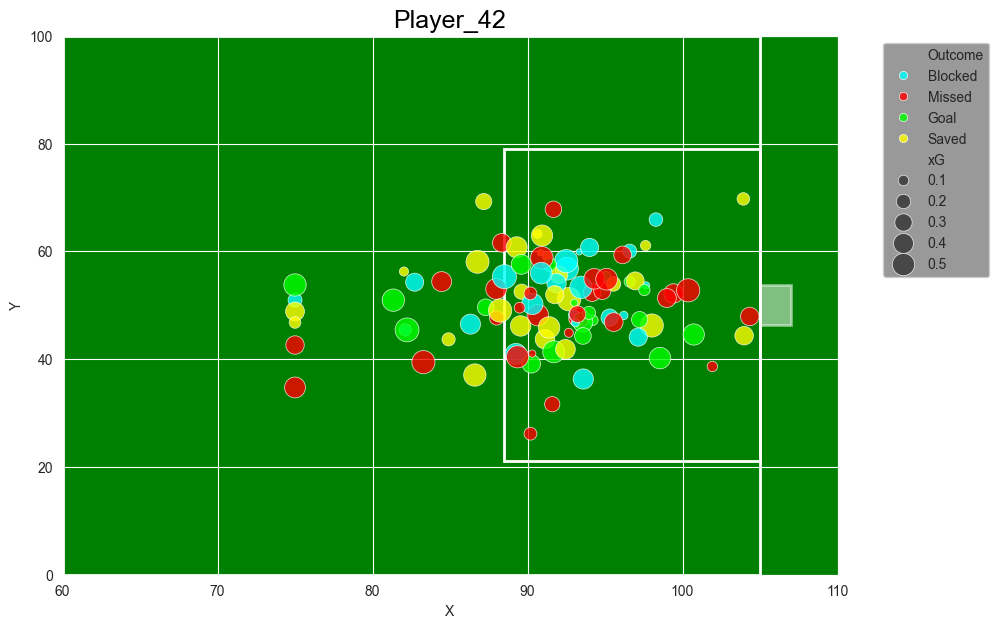

In [14]:
def draw_pitch(ax):
    ax.set_facecolor('green')
    # Limites du terrain (Demi-terrain : X de 60 à 105, Y de 0 à 100)
    plt.plot([60, 60], [0, 100], color="white", linewidth=2)
    plt.plot([105, 105], [0, 100], color="white", linewidth=2) # Ligne de but
    plt.plot([60, 105], [0, 0], color="white", linewidth=2)
    plt.plot([60, 105], [100, 100], color="white", linewidth=2)
    # Surface de réparation
    rect_box = patches.Rectangle((88.5, 21.1), 16.5, 57.8, linewidth=2, edgecolor='white', facecolor='none')
    ax.add_patch(rect_box)
    # But
    rect_goal = patches.Rectangle((105, 46.34), 2, 7.32, linewidth=2, edgecolor='white', facecolor='white', alpha=0.5)
    ax.add_patch(rect_goal)

fig, ax = plt.subplots(figsize=(10, 7))
draw_pitch(ax)

# Scatter plot des tirs
sns.scatterplot(
    data=df_shots, 
    x='X', 
    y='Y', 
    hue='Outcome', 
    size='xG', 
    sizes=(20, 300), 
    palette={'Goal': '#00ff00', 'Saved': '#ffff00', 'Missed': '#ff0000', 'Blocked': '#00ffff'},
    alpha=0.8,
    ax=ax
)

plt.title('Player_42', color='black', fontsize=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', facecolor='gray')
plt.xlim(60, 110)
plt.ylim(0, 100)
plt.show()

La majorité des tirs du joueur42 se trouve à l'intérieur de la surface : il correspond à un joueur qui tire souvent quand y a un fort xG.

## Comparaison Directe

Je vais générer un graphique en barres groupées pour comparer notre cible (Player_42), notre joueur sortant, et la moyenne du championnat. L'objectif est de montrer visuellement les "Gains marginaux" :

Gagnons-nous en pressing ?

Gagnons-nous en création d'occasions (xG) ?

Perdons-nous en jeu aérien ?

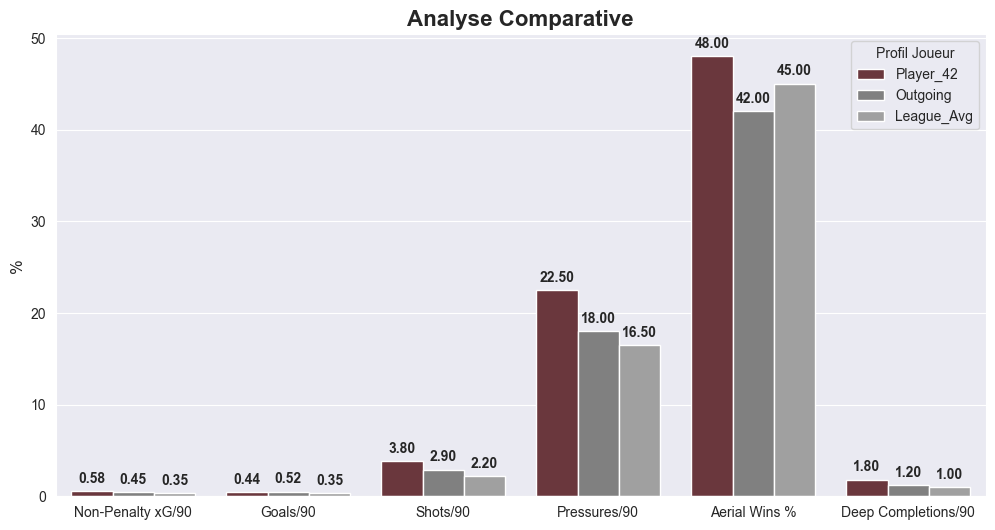

In [15]:
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")
ax = sns.barplot(
    data=df_compare, 
    x='Metric', 
    y='Value', 
    hue='Player',
    palette={'Player_42': '#722f37', 'Outgoing': 'gray', 'League_Avg': '#a0a0a0'}
)
# Annotations pour mettre en valeur les écarts
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.title('Analyse Comparative', fontsize=16, fontweight='bold')
plt.ylabel('%', fontsize=12)
plt.xlabel('')
plt.legend(title='Profil Joueur')
plt.show()

xG/90 : Le Player_42 (bordeaux) est nettement supérieur au joueur sortant (gris). Nous allons créer plus d'occasions.

Pressing : L'écart est significatif. L'équipe récupérera le ballon plus haut.

Note importante : Le joueur sortant a plus de buts réels , mais comme vu dans le premier notebook, c'est une sur-performance temporaire. Le Player_42 offre des fondamentaux statistiques plus solides pour l'avenir.